# Никитин Дмитрий 4217
## Вариант 3: Alcohol Consumption in Russia (1998-2016)
### Задачи:
- Определить регионы с похожими паттернами потребления алкоголя.
- Выявить возможные зависимости между потреблением алкоголя и социально-экономическими характеристиками регионов.
- Сравнить результаты с K-Means кластеризацией.

## Цель работы
Изучить принципы работы самоорганизующихся карт Кохонена (SOM), реализовать модель и провести эксперименты на данных.

## Задание
1. Ознакомиться с принципами работы SOM.
2. Выбрать датасет по варианту.
3. Подготовить датасет, включая предобработку.
4. Реализовать самоорганизующуюся карту Кохонена размером 10x10.
5. Обучить SOM на выбранном датасете, настроив гиперпараметры (размер шага, радиус соседства).
6. Визуализировать результаты в виде топографической карты и цветовой карты кластеров.
7. Сравнить кластеры SOM с известными метками классов (если имеются) и оценить качество кластеризации.
8. Составить отчет с анализом результатов и выводами.


Сначала была произведена загрузка датасета. Известно, что он содержит записи об употреблении алкоголя определённых видов в литрах на душу населения за несколько лет для регионов РФ. Поэтому после загрузки датасета было проведено заполнение пустых полей средним по записям по региону. Если найти среднее невозможно, то использовалось удаление строки с NaN. После чего была произведена группировка по регионам с использованием вычисления среднего.

In [353]:
# Полный импорт
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Частичный импорт
from minisom import MiniSom
from sklearn.cluster import KMeans
from matplotlib.patches import Patch
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler


# 1. Загрузка и предобработка данных
# Загрузка датасета
data = pd.read_csv('data/russia_alcohol.csv')


# Заполнение пропусков средними значениями по региону
for column in ['wine', 'beer', 'vodka', 'champagne', 'brandy']:
    data[column] = data.groupby('region')[column].transform(
        lambda x: x.fillna(x.mean())
    )

# Удаление строк с пропущенными значениями
data = data.dropna()
print(data.info())
# Группируем по регионам, усредняя показатели за все годы
grouped = data.groupby('region').mean().reset_index()



# Выбираем только числовые признаки для кластеризации
X = grouped[['wine', 'beer', 'vodka', 'champagne', 'brandy']].values

# Нормализуем данные
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
grouped.head(5)

<class 'pandas.core.frame.DataFrame'>
Index: 1596 entries, 0 to 1614
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       1596 non-null   int64  
 1   region     1596 non-null   object 
 2   wine       1596 non-null   float64
 3   beer       1596 non-null   float64
 4   vodka      1596 non-null   float64
 5   champagne  1596 non-null   float64
 6   brandy     1596 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 99.8+ KB
None


,region,year,wine,beer,vodka,champagne,brandy
0,Altai Krai,2007.0,3.174211,48.373158,9.465789,1.207368,0.236842
1,Altai Republic,2007.0,5.190000,36.724211,9.683684,0.934737,0.253684
2,Amur Oblast,2007.0,5.221579,53.377368,14.216842,1.115789,0.396842
3,Arkhangelsk Oblast,2007.0,8.670000,47.036842,17.381053,1.631053,0.870526
4,Astrakhan Oblast,2007.0,4.469474,54.695263,9.296842,0.861579,0.361053


Далее инициализируется самоорганизующаяся карта Кохонена (SOM) размером 10×10 нейронов. Указываются параметры: начальный радиус соседства (1.0) и скорость обучения (0.1). Модель создается с этими настройками, веса инициализируются случайно на основе входных данных. Затем SOM обучается 1000 эпох, постепенно адаптируя веса нейронов для отображения структуры данных. Процесс обучения выводится в консоль (verbose=True). В результате формируется двумерная карта, сохраняющая топологию исходного многомерного пространства признаков.

In [354]:
# 2. Создание и обучение SOM
# Параметры SOM
map_size = (10, 10)  # размер карты
input_len = X.shape[1]  # количество входных признаков
sigma = 1.0  # начальный радиус соседства
learning_rate = 0.1  # начальная скорость обучения

# Инициализация SOM
som = MiniSom(map_size[0], map_size[1], input_len, sigma=sigma, learning_rate=learning_rate)

# Инициализация весов случайным образом
som.random_weights_init(X)

# Обучение SOM
num_epochs = 1000
som.train_random(X, num_epochs, verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.10669390129722361


Далее генерируются диаграммы, описывающие данные, полученные от SOM карты.

Сначала была сгенерирована топографическая карта (U-matrix). U-матрица показывает плотность данных в пространстве признаков, где темные области указывают на высокую плотность, а светлые — на низкую. Центральный черный квадрат свидетельствует о наличии плотного кластера, тогда как окружающие светлые области говорят о более разреженном распределении данных. Это помогает выделить основные кластеры и понять структуру данных.

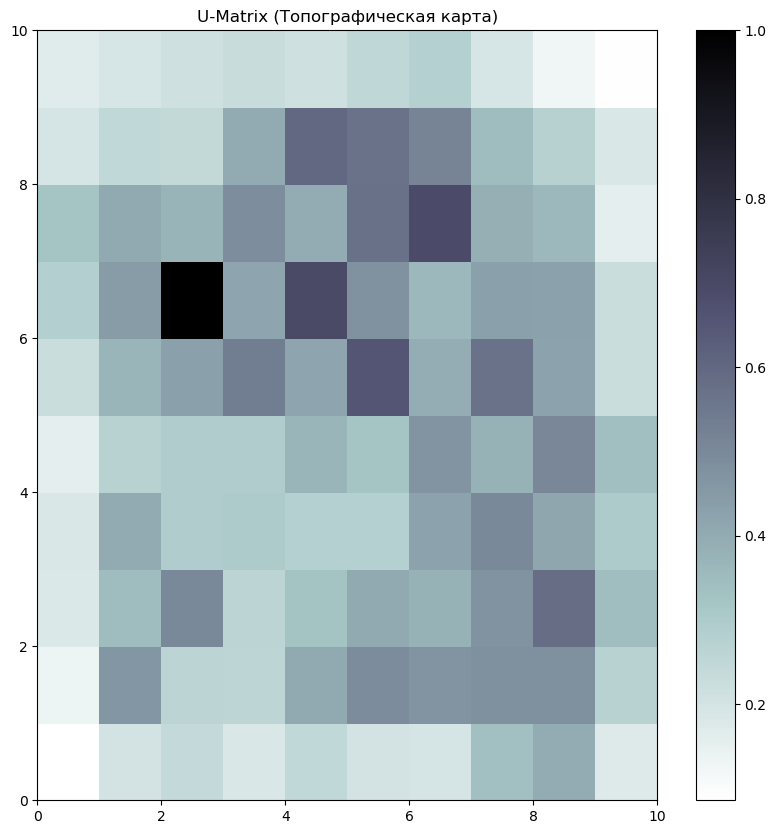

In [355]:
# 3.1. Топографическая карта (U-Matrix)
plt.figure(figsize=(10, 10))
u_matrix = som.distance_map().T  # матрица расстояний между нейронами
plt.pcolor(u_matrix, cmap='bone_r')  # черно-белая карта расстояний
plt.colorbar()
plt.title('U-Matrix (Топографическая карта)')
plt.savefig('U-Matrix.png')
plt.show()

Далее была составлена диаграмма, показывающая количество регионов в каждом нейроне. На данной диаграмме представлено количество регионов в каждом нейроне самоорганизующейся карты (SOM). Цветовая шкала справа показывает количество регионов, где ярко-желтый цвет соответствует наибольшему количеству (4 региона), а темно-фиолетовый — наименьшему (0 регионов). Например, в левом верхнем углу и в центре карты есть нейроны, которые охватывают 4 региона, что указывает на их значимость в кластеризации данных. В то же время большинство нейронов имеют меньшее количество регионов, что видно по преобладанию темно-синих и фиолетовых оттенков. Это свидетельствует о том, что данные распределены неравномерно, и некоторые нейроны играют ключевую роль в представлении кластеров. По данной диаграмме можно предположить, что в данных имеется 3 кластера центрами в жёлтых точках.

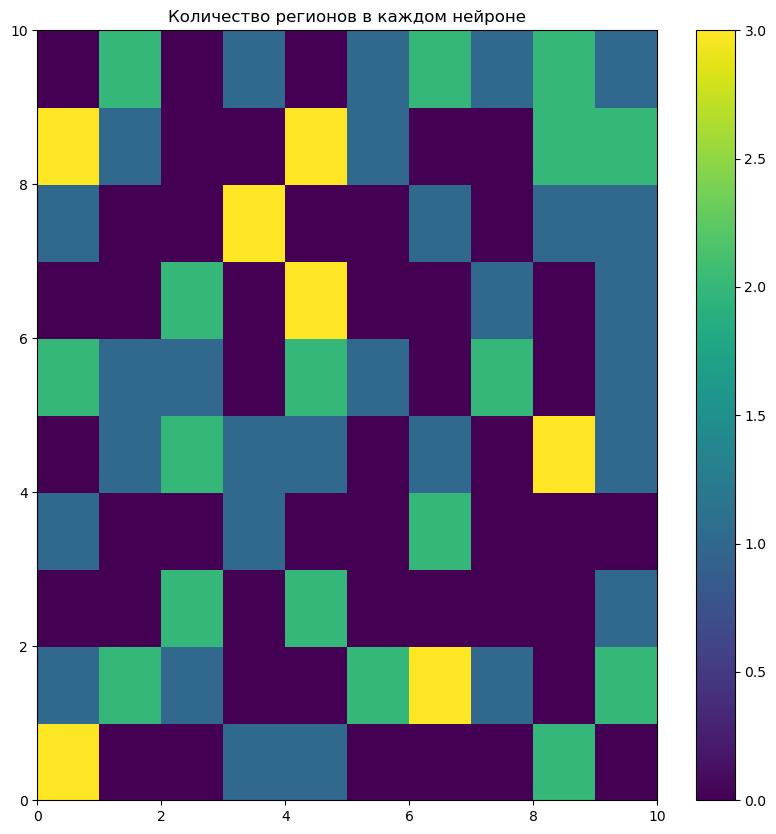

In [356]:
# 3.2. Победители для каждого региона
win_map = som.win_map(X)  # определяем победителей для каждого региона

# Создаем массив с кластерами для каждого региона
cluster_map = np.zeros(map_size)
for win in win_map:
    cluster_map[win] = len(win_map[win])  # количество регионов в каждом нейроне

plt.figure(figsize=(10, 10))
plt.pcolor(cluster_map.T, cmap='viridis')
plt.colorbar()
plt.title('Количество регионов в каждом нейроне')
plt.savefig('cluster-map.png')
plt.show()

Далее была произведена кластеризация на SOM с помощью K-Means. Было выделено 3 кластера экспериментальным путём. Кластеры SOM можно увидеть ниже.

C:\Users\johnworker\.conda\envs\MLLab4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


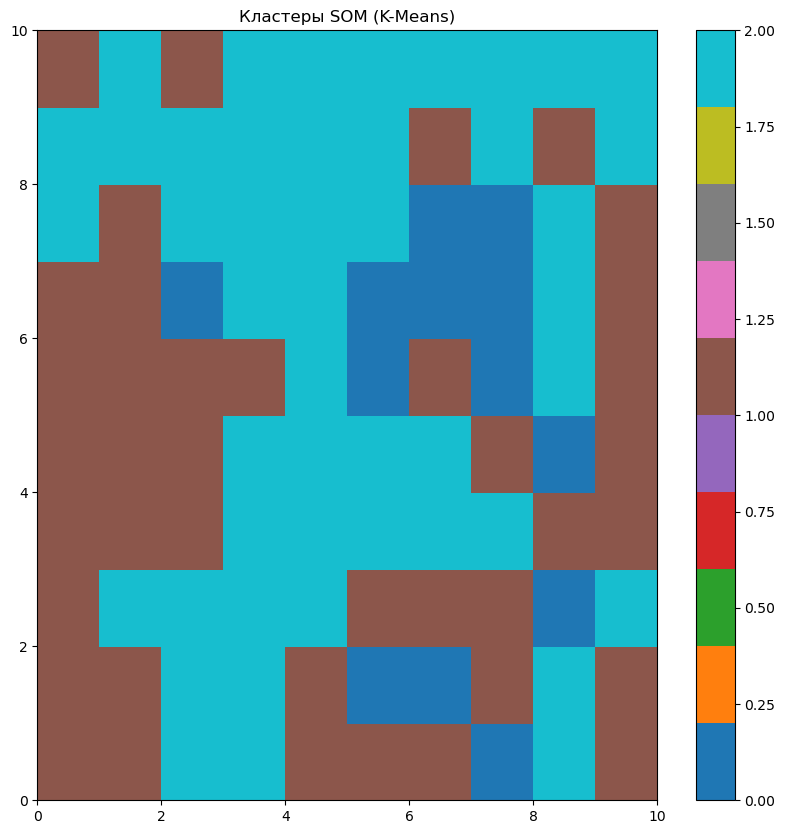

In [357]:
# 3.3. Карта кластеров (используем K-Means для разметки нейронов)
plt.figure(figsize=(10, 10))
som_weights = som.get_weights()  # получаем веса SOM
weights = som_weights.reshape(-1, input_len)  # преобразуем в 2D массив

# Применяем K-Means к весам SOM
kmeans = KMeans(n_clusters=3, random_state=10)
kmeans.fit(weights)

# Визуализируем кластеры
cluster_labels = kmeans.labels_.reshape(map_size)
plt.pcolor(cluster_labels.T, cmap='tab10')
plt.colorbar()
plt.title('Кластеры SOM (K-Means)')
plt.savefig('k-means.png')
plt.show()

Далее была проведена прямая кластеризация K-Means.

C:\Users\johnworker\.conda\envs\MLLab4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


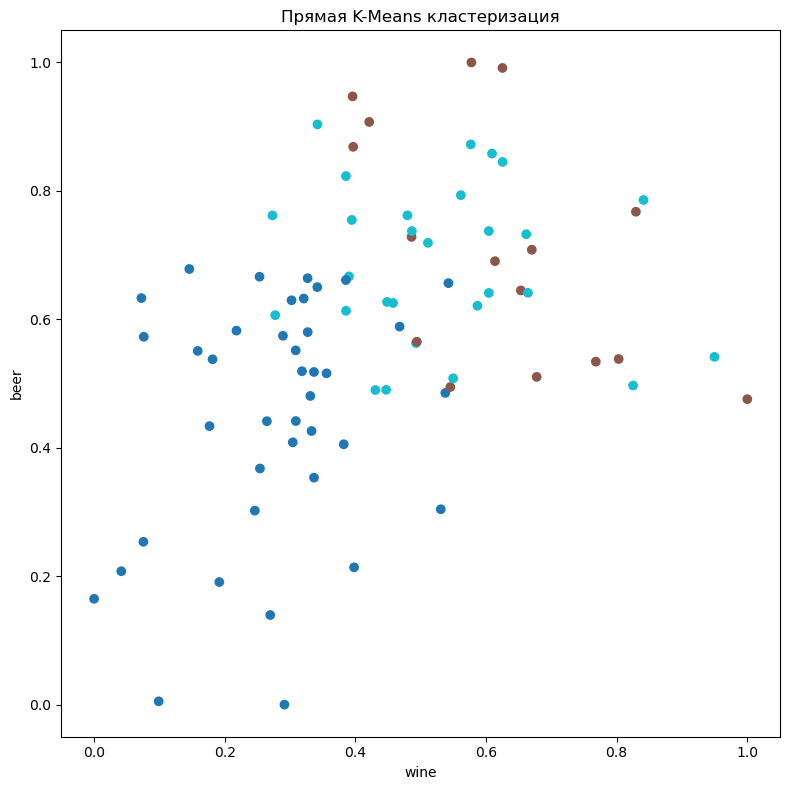

In [358]:
# 3.4. Сравнение с K-Means (прямая кластеризация данных)
plt.figure(figsize=(8, 8))
kmeans_direct = KMeans(n_clusters=3, random_state=10)
direct_labels = kmeans_direct.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=direct_labels, cmap='tab10')
plt.title('Прямая K-Means кластеризация')
plt.xlabel('wine')
plt.ylabel('beer')

plt.tight_layout()
plt.savefig('strait k-means.png')
plt.show()

Прямая кластеризация K-Means также показала, что значение количества кластеров равное трём отлично подходит для данного датасета и скорее всего совпадает с естественным количеством кластеров.

In [359]:
# 4. Анализ результатов
# Находим регионы в каждом кластере SOM
grouped['som_cluster'] = np.nan
for i, x in enumerate(X):
    winner = som.winner(x)  # находим победителя для каждого региона
    grouped.loc[i, 'som_cluster'] = cluster_labels[winner]  # записываем кластер

# Анализируем топ-регионы по потреблению алкоголя в каждом кластере
for cluster in range(3):
    print(f"\nКластер {cluster}:")
    cluster_data = grouped[grouped['som_cluster'] == cluster]
    top_regions = cluster_data.sort_values('vodka', ascending=False).head(3)
    print(top_regions[['region', 'wine', 'beer', 'vodka', 'champagne', 'brandy']])

     # Средние значения потребления алкоголя в кластере
    mean_consumption = cluster_data[['wine', 'beer', 'vodka', 'champagne', 'brandy']].mean()
    print("\nСреднее потребление алкоголя в кластере:")
    print(mean_consumption)


Кластер 0:
            region      wine       beer      vodka  champagne    brandy
22   Komi Republic  9.223684  65.744211  20.654211   1.697368  0.810000
16  Kamchatka Krai  7.278421  59.572105  19.712105   2.736842  1.245263
32          Moscow  7.381579  83.688421  19.022105   4.386316  1.257895

Среднее потребление алкоголя в кластере:
wine          7.128702
beer         62.451088
vodka        16.673825
champagne     2.151439
brandy        1.018596
dtype: float64

Кластер 1:
             region      wine       beer      vodka  champagne    brandy
79   Vologda Oblast  9.328421  67.206842  17.217895   0.857368  0.517895
66  Smolensk Oblast  7.708947  62.943684  15.755789   1.615263  0.506842
18  Kemerovo Oblast  5.262105  57.677368  15.605263   1.209474  0.484737

Среднее потребление алкоголя в кластере:
wine          6.785329
beer         57.652083
vodka        13.494803
champagne     1.332675
brandy        0.545066
dtype: float64

Кластер 2:
                  region      wine      

Итог:
- Кластер 0: "Высокое потребление пива и водки" — доминируют пиво и водка.
- Кластер 1: "Умеренное потребление с акцентом на пиво" — пиво доминирует, но водка также важна.
- Кластер 2: "Низкое потребление алкоголя" — все виды алкоголя потребляются в минимальных количествах.

Далее была проведена математическая оценка кластеризации каждого метода и их сравнение.


Метрика силуэта для K-Means: 0.264
Метрика силуэта для SOM + K-Means: 0.264


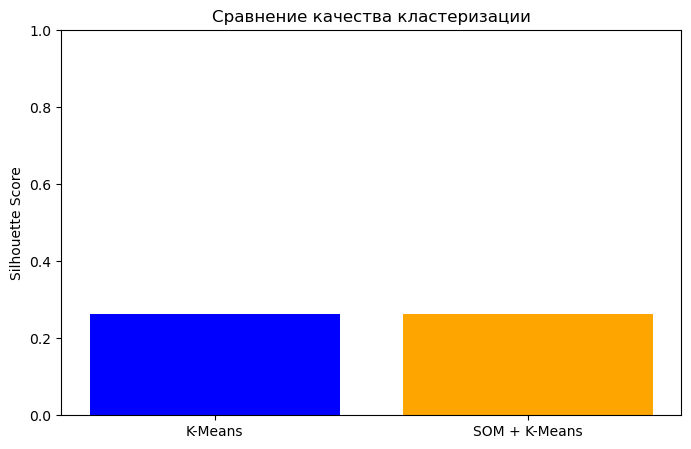


Индекс согласованности кластеризаций (ARI): 0.717


In [360]:
# 5. Сравнение SOM и K-Means с метрикой силуэта
grouped['kmeans_cluster'] = direct_labels

# Вычисляем метрику силуэта для прямого K-Means
silhouette_kmeans = silhouette_score(X, direct_labels)
print(f"\nМетрика силуэта для K-Means: {silhouette_kmeans:.3f}")

# Вычисляем метрику силуэта для SOM + K-Means
som_cluster_labels = np.array([cluster_labels[som.winner(x)] for x in X])
silhouette_som = silhouette_score(X, som_cluster_labels)
print(f"Метрика силуэта для SOM + K-Means: {silhouette_som:.3f}")

# Визуализация метрик силуэта
plt.figure(figsize=(8, 5))
plt.bar(['K-Means', 'SOM + K-Means'], [silhouette_kmeans, silhouette_som], color=['blue', 'orange'])
plt.ylabel('Silhouette Score')
plt.title('Сравнение качества кластеризации')
plt.ylim(0, 1)
plt.savefig('silhouette.png')
plt.show()
from sklearn.metrics import adjusted_rand_score
# Проверяем согласованность кластеризации
ari = adjusted_rand_score(grouped['som_cluster'], grouped['kmeans_cluster'])
print(f"\nИндекс согласованности кластеризаций (ARI): {ari:.3f}")

В ходе анализа кластеризации данных о потреблении алкоголя в регионах России были применены два метода: K-Means и комбинация самоорганизующейся карты (SOM) с K-Means. Оба подхода показали похожую метрику силуэта (около 0.26), что указывает на умеренное качество кластеризации и возможное перекрытие данных между кластерами. Это может свидетельствовать о сложной структуре данных, где четкие границы между кластерами отсутствуют. Индекс согласованности кластеризаций (ARI) в 0.717 подтверждает высокую степень сходства между результатами двух методов, хотя и не идеальную. Таким образом, оба подхода дают схожие результаты, но для улучшения качества кластеризации можно рассмотреть использование других методов.